In [1]:
#!git clone https://github.com/whyhardt/SPICE.git

In [2]:
# !pip install -e SPICE

In [3]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from spice import SpiceEstimator, SpiceConfig, csv_to_dataset, BaseModel, plot_session, split_data_along_sessiondim

sys.path.append('../../..')
from weinhardt2026.utils.benchmarking_gru import GRUModel, training
from weinhardt2026.studies.braun2018.benchmarking_braun2018 import ExpectedValueControl, get_dataset, generate_behavior

# For custom RNN
import torch
import torch.nn as nn

# NOTEBOOK CONFIG

In [4]:
train_spice = False
train_evc = False
train_gru = False

# DATASET

## Load dataset

In [5]:
dataset_train, dataset_test, _ = get_dataset(verbose=True)

Shape of dataset: torch.Size([756, 274, 1, 10])
Number of participants: 63
Number of actions in dataset: 2


## Dataset processing

In [6]:
# seems like there are a few blocks that are way longer than the average block
# maybe limiting the block length to a given size would help
n_trials_per_block = np.zeros(dataset_train.xs.shape[0])
for index, block in enumerate(dataset_train.xs[:, :, 0, 0]):
    n_trials_per_block[index] = block.shape[0]-block.isnan().sum()

mean, std = n_trials_per_block.mean(), n_trials_per_block.std()

print(f"Average sequence length: {int(mean)}+-{int(std)}")
print(f"Old max sequence length is {dataset_train.xs.shape[1]}")

# it would be okay to limit until ca mean+2*std trials per  (~200 trials)
dataset_train.xs = dataset_train.xs[:, :int(mean+2*std)]
dataset_train.ys = dataset_train.ys[:, :int(mean+2*std)]

print(f"New max sequence length is {dataset_train.xs.shape[1]}")

Average sequence length: 66+-39
Old max sequence length is 274
New max sequence length is 145


In [7]:
# seems like there are a few blocks that are way longer than the average block
# maybe limiting the block length to a given size would help
n_trials_per_block = np.zeros(dataset_test.xs.shape[0])
for index, block in enumerate(dataset_test.xs[:, :, 0, 0]):
    n_trials_per_block[index] = block.shape[0]-block.isnan().sum()

mean, std = n_trials_per_block.mean(), n_trials_per_block.std()

print(f"Average sequence length: {int(mean)}+-{int(std)}")
print(f"Old max sequence length is {dataset_test.xs.shape[1]}")

# it would be okay to limit until ca mean+2*std trials per  (~200 trials)
dataset_test.xs = dataset_test.xs[:, :int(mean+2*std)]
dataset_test.ys = dataset_test.ys[:, :int(mean+2*std)]

print(f"New max sequence length is {dataset_test.xs.shape[1]}")

Average sequence length: 67+-34
Old max sequence length is 274
New max sequence length is 136


# SPICE

## SPICE Setup

Thoughts on SPICE architecture:

1. Reward and Effort sensitivity -> Separate values for reward and effort
2. Include effort levels for both tasks
3. Item-Space -> Task-Space -> Enables tracking task-individual values (e.g. some people might find easier to say color and others prefer form) 
4. Action-Space -> Repeat/Switch or specific Task-Selection?
5. Include separate module for repeat/switch bias -> May be unncessary because could be encoded already in effort modules
6. Include previous response time as input to repeat/switch bias
7. Account for length of experiment as cognitive control becomes more costly over time i.e. blocks ("We predict that the indifference point will increase as the experiment progresses")
8. Check whether state-less implementation makes sense -> Everything is given in cues (rewards for each task; effort levels could be directly predicted using last n actions) vs state-based dynamical model (evolution of effort/reward values over trials)

On repeat/switch bias:

"control becomes increasingly costly as it is exerted for a longer period of time" - Braun (2018)
-> Switching to keep optimal reward strength cannot be done over an extended period
-> Repeat/Switch ratio is probabily very unbalanced while Task-Ratio should be more or less counterbalanced -> **Benefit of acting on Task-Space instead of Repeat/Switch-Space**

Now we are going to define the configuration for SPICE with a `SpiceConfig` object.

The `SpiceConfig` takes as arguments 
1. `library_setup (dict)`: Defining the variable names of each module.
2. `memory_state (dict)`: Defining the memory state variables and their initial values.
3. `states_in_logit (list)`: Defining which of the memory state variables are used later for the logit computation. This is necessary for some background processes.  

In [8]:
spice_config = SpiceConfig(
    library_setup={
        'reward_repeat': (
            'dreward_tasks', 
            # 'dreward_trials_repeat',
            # 'dreward_trials_switch',
            ),
        'reward_switch': (
            'dreward_tasks',
            # 'dreward_trials_repeat',
            # 'dreward_trials_switch', 
            ),
        'task_repeat': (
            'repeat',
            ),
        'task_switch': (
            'repeat',
            ),
        'fatigue_repeat': (
            'block',
            ),
        'fatigue_switch': (
            'block',
            ),
    },
    memory_state={
        'value_reward': None,
        'value_control': None,
        'value_fatigue': None,
    },
)

And now we are going to define the SPICE model which is a child of the `BaseModel` and `torch.nn.Module` class and takes as required arguments:
1. `spice_config (SpiceConfig)`: previously defined SpiceConfig object
2. `n_actions (int)`: number of possible actions in your dataset (including non-displayed ones if applicable).
3. `n_participants (int)`: number of participants in your dataset.

As usual for a `torch.nn.Module` we have to define at least the `__init__` method and the `forward` method.
The `forward` method gets called when computing a forward pass through the model and takes as inputs `(inputs (SpiceDataset.xs), prev_state (dict, default: None), batch_first (bool, default: False))` and returns `(logits (torch.Tensor, shape: (n_participants*n_blocks*n_experiments, timesteps, n_actions)), updated_state (dict))`. Two necessary method calls inside the forward pass are:
1. `self.init_forward_pass(inputs, prev_state) -> SpiceSignals`: returns a `SpiceSignals` object which carries all relevant information already processed.
2. `self.post_forward_pass(SpiceSignals, batch_first) -> SpiceSignals`: does some re-arranging of the logits to adhere to `batch_first`.

In [9]:
class SpiceModel(BaseModel):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        
        self.dropout = 0.1
        self.n_blocks = 12
        
        self.participant_embedding = self.setup_embedding(num_embeddings=self.n_participants, embedding_size=self.embedding_size, dropout=self.dropout)
        
        self.setup_module(key_module='reward_repeat', input_size=1, dropout=self.dropout, include_state=False)
        self.setup_module(key_module='reward_switch', input_size=1, dropout=self.dropout, include_state=False)
        self.setup_module(key_module='task_repeat', input_size=1, dropout=self.dropout)
        self.setup_module(key_module='task_switch', input_size=1, dropout=self.dropout)
        self.setup_module(key_module='fatigue_repeat', input_size=1, dropout=self.dropout, include_state=False)        
        self.setup_module(key_module='fatigue_switch', input_size=1, dropout=self.dropout, include_state=False)        
        
    def forward(self, inputs, prev_state=None):
        
        spice_signals = self.init_forward_pass(inputs, prev_state)
        
        dreward_tasks_current = -spice_signals.additional_inputs[..., 0].unsqueeze(-1).expand_as(spice_signals.actions)
        dreward_tasks_other = spice_signals.additional_inputs[..., 0].unsqueeze(-1).expand_as(spice_signals.actions)
        dreward_trials_current = spice_signals.additional_inputs[..., 1].unsqueeze(-1).expand_as(spice_signals.actions)
        dreward_trials_other = spice_signals.additional_inputs[..., 2].unsqueeze(-1).expand_as(spice_signals.actions)
        # rt = spice_signals.additional_inputs[..., 3].unsqueeze(-1).expand_as(spice_signals.actions)
        blocks = spice_signals.blocks.unsqueeze(0).unsqueeze(-1).expand_as(spice_signals.actions[0]) / self.n_blocks
        
        repeat = torch.zeros_like(spice_signals.actions)
        repeat += spice_signals.actions[..., :1]
        switch = torch.zeros_like(spice_signals.actions)
        switch += spice_signals.actions[..., 1:2]
        
        repeat_mask = torch.zeros_like(spice_signals.actions[0])
        repeat_mask[..., 0] = 1
        switch_mask = torch.zeros_like(spice_signals.actions[0])
        switch_mask[..., 1] = 1
        
        participant_embedding = self.participant_embedding(spice_signals.participant_ids)
        
        for trial in spice_signals.trials:
            
            # modules for reward perception
            value_reward_repeat = self.call_module(
                key_module='reward_repeat',
                # key_state='value_reward',
                action_mask=repeat_mask,
                inputs=dreward_tasks_current[trial],
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )
            value_reward_switch = self.call_module(
                key_module='reward_switch',
                # key_state='value_reward',
                action_mask=switch_mask,
                inputs=dreward_tasks_other[trial],
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )
            
            # modules to update switching costs
            self.call_module(
                key_module='task_repeat',
                key_state='value_control',
                action_mask=repeat_mask,
                inputs=repeat[trial],
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )
            self.call_module(
                key_module='task_switch',
                key_state='value_control',
                action_mask=switch_mask,
                inputs=repeat[trial],
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )
            
            # module to update fatigue value based on current block number
            value_fatigue_repeat = self.call_module(
                key_module='fatigue_repeat',
                # key_state='value_fatigue',
                action_mask=repeat_mask,
                inputs=blocks,
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )
            value_fatigue_switch = self.call_module(
                key_module='fatigue_switch',
                # key_state='value_fatigue',
                action_mask=switch_mask,
                inputs=blocks,
                participant_index=spice_signals.participant_ids,
                participant_embedding=participant_embedding,
            )
            
            # compute logits
            spice_signals.logits[trial] = (
                value_reward_repeat+value_reward_switch
                + self.state['value_control'] 
                + value_fatigue_repeat+value_fatigue_switch
                )
        
        spice_signals = self.post_forward_pass(spice_signals)
        return spice_signals.logits, self.state


Let's setup now the `SpiceEstimator` object and fit it to the data!

In [10]:
path_spice = 'params/spice_braun2018_stage1.pkl'

estimator = SpiceEstimator(
        # model paramaeters
        spice_class=SpiceModel,
        spice_config=spice_config,
        n_actions=2,
        n_participants=dataset_train.n_participants,
        n_experiments=1,
        n_reward_features=0,
        
        epochs=1000,
        warmup_steps=250,

        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        verbose=True,
        save_path_spice=path_spice,
    )

In [11]:
if train_spice:
    estimator.fit(dataset_train.xs, dataset_train.ys, dataset_test.xs, dataset_test.ys)

In [12]:
estimator.load_spice(path_spice)

# BENCHMARKING

### Expected Value of Control Model (Shenhav et al., 2013)

In [13]:
path_spice = 'params/spice_braun2018.pkl'

evc = ExpectedValueControl(n_participants=dataset_train.n_participants)
path_evc = path_spice.replace('spice_', 'evc_')

In [14]:
if train_evc:
    optimizer_evc = torch.optim.Adam(evc.parameters(), lr=0.01)
    epochs = 1000

    evc = training(
        model=evc,
        optimizer=optimizer_evc,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        epochs=epochs,
        device=torch.device('cpu'),
    )

    torch.save(evc.state_dict(), path_evc)

In [15]:
evc.load_state_dict(torch.load(path_evc, map_location='cpu'))

<All keys matched successfully>

### GRU Model

In [16]:
gru = GRUModel(dataset_train.n_actions, additional_inputs=4, n_reward_features=0)
path_gru = path_spice.replace('spice_', 'gru_')

In [17]:
if train_gru:
    epochs = 1000
    optimizer_gru = torch.optim.Adam(gru.parameters(), lr=0.01)

    gru = training(
        model=gru.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu')),
        optimizer=optimizer_gru,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        epochs=epochs,
        ).to(torch.device('cpu'))

    torch.save(gru.state_dict(), path_gru)

In [18]:
gru.load_state_dict(torch.load(path_gru, map_location='cpu'))
# gru.to(torch.device('cpu')).eval()

<All keys matched successfully>

# ANALYSIS

In [19]:
from weinhardt2026.analysis.analysis_model_evaluation import analysis_model_evaluation
from weinhardt2026.analysis.analysis_coefficients_distributions import analysis_coefficients_distributions
from weinhardt2026.analysis.analysis_coefficients_individuals import analysis_coefficients_individuals

## Analysis model evaluation

In [20]:
print("Model evaluation on training data (for AIC and BIC): ")
analysis_model_evaluation(
    dataset=dataset_train,
    spice_model=estimator,
    benchmark_model=evc,
    gru_model=gru,
)

Model evaluation on training data (for AIC and BIC): 
Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC
Benchmark,0.570419,0.155806,5.000000,0.000000,20643.751953,41297.503906,41340.066406
GRU,0.696628,0.152761,1810.000000,0.000000,13293.589844,30207.179688,45614.835938
SPICE-RNN,0.656847,0.147452,12368.000000,0.000000,15455.841797,55647.683594,160930.515625
SPICE,0.647984,0.150829,17.444445,0.708355,15955.406250,31945.701172,32094.197266


In [21]:
print("Model evaluation on held-out data (for average trial likelihood and NLL): ")
analysis_model_evaluation(
    dataset=dataset_test,
    spice_model=estimator,
    benchmark_model=evc,
    gru_model=gru,
)

Model evaluation on held-out data (for average trial likelihood and NLL): 
Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC
Benchmark,0.546326,0.159768,5.000000,0.00000,7515.628906,15041.257812,15078.398438
GRU,0.662498,0.155989,1810.000000,0.00000,5118.724609,13857.449219,27302.181641
SPICE-RNN,0.644013,0.143054,12368.000000,0.00000,5470.540527,35677.082031,127546.945312
SPICE,0.636359,0.146608,17.444445,0.70961,5619.178223,11273.245117,11402.823242


## Analysis generative behavior

In [22]:
generated_dataset_spice = generate_behavior(
    dataset=dataset_train,
    model=estimator,
    save_dataset='data/braun2018_spice.csv'
)

generated_dataset_benchmark = generate_behavior(
    dataset=dataset_train,
    model=evc,
    save_dataset='data/braun2018_benchmark.csv'
)

generated_dataset_gru = generate_behavior(
    dataset=dataset_train,
    model=gru,
    save_dataset='data/braun2018_gru.csv'
)

Generating behavior...


100%|██████████| 145/145 [00:01<00:00, 83.70it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 145/145 [00:00<00:00, 431.72it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 145/145 [00:00<00:00, 221.90it/s]


Done generating behavior.


In [23]:
from analysis_generative import analysis_generative_behavior

Loading real from data/braun2018.csv...
Loading benchmark from data/braun2018_benchmark.csv...
Loading gru from data/braun2018_gru.csv...
Loading spice_rnn from data/braun2018_spice.csv...
Loading spice from data/braun2018_spice.csv...
                 P(Switch) P(Switch | Both Change) P(Switch | Neither Change)  \
Model                                                                           
real       0.368 +/- 0.273         0.299 +/- 0.266            0.412 +/- 0.321   
benchmark  0.373 +/- 0.238         0.383 +/- 0.261            0.361 +/- 0.271   
gru        0.443 +/- 0.186         0.436 +/- 0.226            0.437 +/- 0.231   
spice_rnn  0.331 +/- 0.193         0.329 +/- 0.219            0.331 +/- 0.225   
spice      0.331 +/- 0.193         0.329 +/- 0.219            0.331 +/- 0.225   

          P(Switch | Current Decrease) P(Switch | Other Increase)  \
Model                                                               
real                   0.337 +/- 0.266            0.339 +/

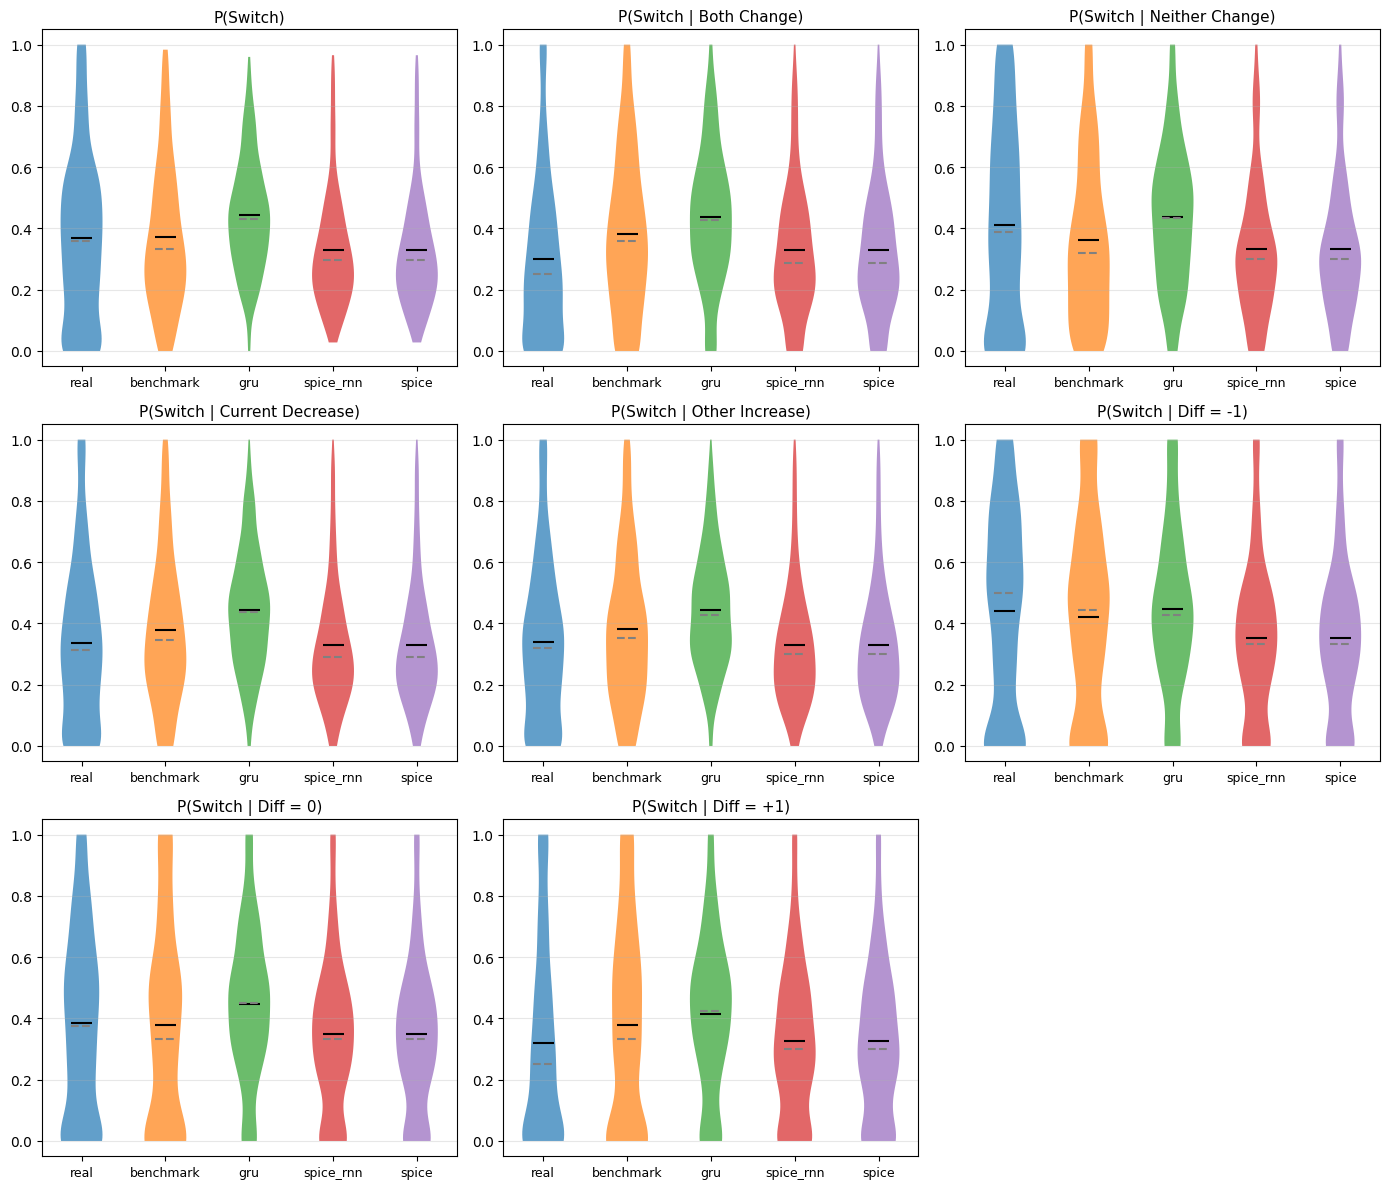


Per-metric MAE (|model_mean - real_mean|):
          P(Switch) P(Switch | Both Change) P(Switch | Neither Change)  \
Model                                                                    
benchmark    0.0051                  0.0845                     0.0507   
gru          0.0756                  0.1373                     0.0248   
spice_rnn    0.0366                  0.0299                     0.0805   
spice        0.0366                  0.0299                     0.0805   

          P(Switch | Current Decrease) P(Switch | Other Increase)  \
Model                                                               
benchmark                       0.0413                     0.0438   
gru                             0.1078                     0.1038   
spice_rnn                       0.0070                     0.0083   
spice                           0.0070                     0.0083   

          P(Switch | Diff = -1) P(Switch | Diff = 0) P(Switch | Diff = +1)  \
Model             

(                 P(Switch) P(Switch | Both Change) P(Switch | Neither Change)  \
 Model                                                                           
 real       0.368 +/- 0.273         0.299 +/- 0.266            0.412 +/- 0.321   
 benchmark  0.373 +/- 0.238         0.383 +/- 0.261            0.361 +/- 0.271   
 gru        0.443 +/- 0.186         0.436 +/- 0.226            0.437 +/- 0.231   
 spice_rnn  0.331 +/- 0.193         0.329 +/- 0.219            0.331 +/- 0.225   
 spice      0.331 +/- 0.193         0.329 +/- 0.219            0.331 +/- 0.225   
 
           P(Switch | Current Decrease) P(Switch | Other Increase)  \
 Model                                                               
 real                   0.337 +/- 0.266            0.339 +/- 0.264   
 benchmark              0.378 +/- 0.242            0.383 +/- 0.245   
 gru                    0.445 +/- 0.198            0.443 +/- 0.196   
 spice_rnn              0.330 +/- 0.203            0.331 +/- 0.203   
 spi

In [24]:
analysis_generative_behavior(
    path_data_real='data/braun2018.csv',
    path_data_benchmark='data/braun2018_benchmark.csv',
    path_data_gru='data/braun2018_gru.csv',
    path_data_spice_rnn='data/braun2018_spice.csv',
    path_data_spice='data/braun2018_spice.csv',
)

## Analysis coefficient distribution

In [27]:
analysis_coefficients_distributions(
    spice_model=estimator,
    output_dir='results',
)

Extracting coefficient data...
  Ensemble=10, Participants=63, Experiments=1, Modules=6, Total terms=24

ANALYSIS 1: Ensemble Consistency
  Mean presence agreement: 1.000
  Mean presence rate:      0.727
  Mean CV:                 1.184
  Ensemble spread plots saved.
  Ensemble CV heatmaps saved.

ANALYSIS 2: Coefficient Distributions
  Terms with >50% presence: 18 / 24
  Terms with 0% presence:   4 / 24
  Violin plots saved.
  Presence rate bar chart saved.
  Experiment comparison skipped (X=1).
  Sparsity heatmaps saved.

All results saved to: results


(            module                term  term_index  presence_agreement_mean  \
 0    reward_repeat                   1           0                      1.0   
 1    reward_repeat       dreward_tasks           1                      1.0   
 2    reward_repeat     dreward_tasks^2           2                      1.0   
 3    reward_switch                   1           0                      1.0   
 4    reward_switch       dreward_tasks           1                      1.0   
 5    reward_switch     dreward_tasks^2           2                      1.0   
 6      task_repeat                   1           0                      1.0   
 7      task_repeat         task_repeat           1                      1.0   
 8      task_repeat              repeat           2                      1.0   
 9      task_repeat       task_repeat^2           3                      1.0   
 10     task_repeat  task_repeat*repeat           4                      1.0   
 11     task_repeat            repeat^2 

## Analysis coefficients individuals